In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [4]:
df=pd.read_csv("C://Users//lenovo//Downloads//archive (3)//global_cancer_patients_2015_2024.csv")

In [5]:
df.head()

,Patient_ID,Age,Gender,Country_Region,Year,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Cancer_Type,Cancer_Stage,Treatment_Cost_USD,Survival_Years,Target_Severity_Score
0,PT0000000,71,Male,UK,2021,6.4,2.8,9.5,0.9,8.7,Lung,Stage III,62913.44,5.9,4.92
1,PT0000001,34,Male,China,2021,1.3,4.5,3.7,3.9,6.3,Leukemia,Stage 0,12573.41,4.7,4.65
2,PT0000002,80,Male,Pakistan,2023,7.4,7.9,2.4,4.7,0.1,Breast,Stage II,6984.33,7.1,5.84
3,PT0000003,40,Male,UK,2015,1.7,2.9,4.8,3.5,2.7,Colon,Stage I,67446.25,1.6,3.12
4,PT0000004,43,Female,Brazil,2017,5.1,2.8,2.3,6.7,0.5,Skin,Stage III,77977.12,2.9,3.62


## Project Vision - EDA on Cancer Dataset

This project harnesses the power of advanced analytics and global health data to uncover actionable insights into cancer care, outcomes, and disparities. Using a robust dataset of 50,000 cancer patient records collected from multiple countries between 2015 and 2024, we aim to bridge the gap between raw data and life-saving decisions.

### What the Data Covers

* Our dataset offers a 360-degree view of cancer patient profiles, including:

* Demographics: Age, gender, country, year of diagnosis.

* Genetic & Lifestyle Risks: Genetic predisposition, smoking, alcohol use, obesity

* Environmental Exposure: Air pollution

* Clinical & Economic Variables: Cancer type, stage, treatment cost

* Patient Outcomes: Survival years, severity scores

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Patient_ID             50000 non-null  object 
 1   Age                    50000 non-null  int64  
 2   Gender                 50000 non-null  object 
 3   Country_Region         50000 non-null  object 
 4   Year                   50000 non-null  int64  
 5   Genetic_Risk           50000 non-null  float64
 6   Air_Pollution          50000 non-null  float64
 7   Alcohol_Use            50000 non-null  float64
 8   Smoking                50000 non-null  float64
 9   Obesity_Level          50000 non-null  float64
 10  Cancer_Type            50000 non-null  object 
 11  Cancer_Stage           50000 non-null  object 
 12  Treatment_Cost_USD     50000 non-null  float64
 13  Survival_Years         50000 non-null  float64
 14  Target_Severity_Score  50000 non-null  float64
dtypes:

In [11]:
df.isnull().sum() #there is no null values in our data set

Patient_ID               0
Age                      0
Gender                   0
Country_Region           0
Year                     0
Genetic_Risk             0
Air_Pollution            0
Alcohol_Use              0
Smoking                  0
Obesity_Level            0
Cancer_Type              0
Cancer_Stage             0
Treatment_Cost_USD       0
Survival_Years           0
Target_Severity_Score    0
dtype: int64

In [12]:
df.duplicated().sum() #no duplicates

np.int64(0)

### Discriptive Analysis

In [14]:
# AGE column

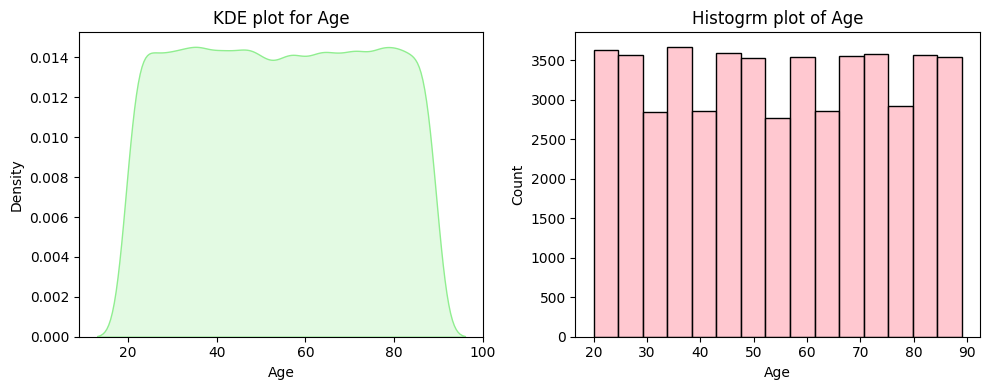

In [15]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.kdeplot(data=df["Age"],fill=True,color="lightgreen")
plt.title("KDE plot for Age")

plt.subplot(1,2,2)
sns.histplot(data=df["Age"],bins=15,color="lightpink")
plt.title("Histogrm plot of Age")

plt.tight_layout()
plt.show()

In [16]:
df["Age"].describe()

count    50000.000000
mean        54.421540
std         20.224451
min         20.000000
25%         37.000000
50%         54.000000
75%         72.000000
max         89.000000
Name: Age, dtype: float64

#### Inference of Age 

* Most Patients Are Middle-Aged to Elderly
* The mean (54.4) and median (54) are almost equal.
* Cancer affects a broad age range (20–89 years).
* Quartile Interpretation  
   25% of patients are below 37 years

   50% are below 54 years

   75% are below 72 years
* The distribution appears fairly balanced without heavy skewness.
* Age is likely a significant factor in cancer risk analysis.

In [19]:
# Gender

In [20]:
df["Gender"].value_counts()

Gender
Male      16796
Female    16709
Other     16495
Name: count, dtype: int64

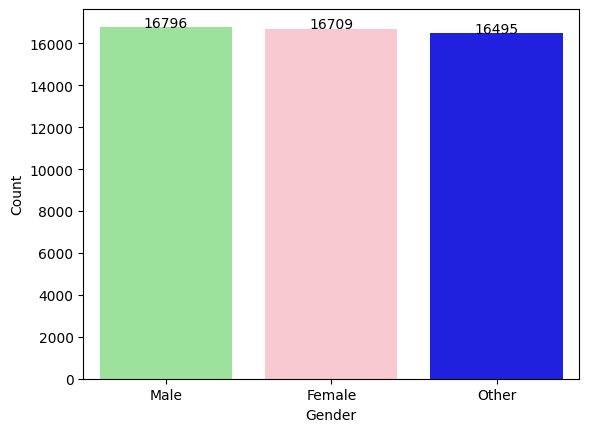

In [21]:
sns.barplot(x=df["Gender"].value_counts().index,y=df["Gender"].value_counts().values,color="lightblue",palette=["lightgreen","pink","blue"])
for x,v in enumerate(df["Gender"].value_counts()):
    plt.text(x,v,str(v),ha="center")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

#### Inference of Gender

* The number of patients across all three gender categories is almost equal.
* The dataset is well-balanced across genders, making it suitable for:

  Gender-based survival analysis

  Treatment cost comparison

  Risk factor comparison

  Cancer type prevalence by gender

In [24]:
# country column

In [25]:
df["Country_Region"].value_counts()

Country_Region
Australia    5092
UK           5060
USA          5060
India        5040
Germany      5024
Russia       5017
Brazil       5004
Pakistan     4926
China        4913
Canada       4864
Name: count, dtype: int64

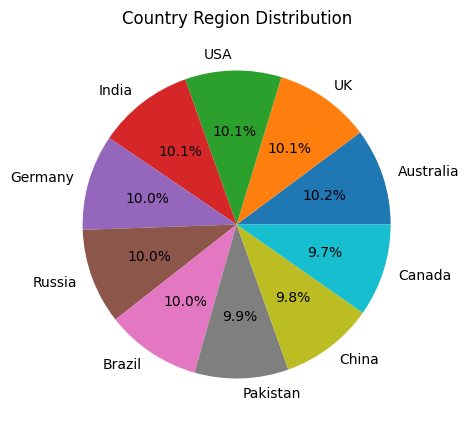

In [26]:
plt.figure(figsize=(5,5))
plt.pie(x=df["Country_Region"].value_counts().values,labels=df["Country_Region"].value_counts().index,autopct="%1.1f%%")
plt.title("Country Region Distribution")
plt.show()

#### Inferences

* Nearly Equal Global Representation

* Each country contributes approximately 5,000 patients (~10%).

* There is no major geographical bias, which strengthens the reliability of global insights.

* Comparative survival and treatment cost studies

In [29]:
df.columns

Index(['Patient_ID', 'Age', 'Gender', 'Country_Region', 'Year', 'Genetic_Risk',
       'Air_Pollution', 'Alcohol_Use', 'Smoking', 'Obesity_Level',
       'Cancer_Type', 'Cancer_Stage', 'Treatment_Cost_USD', 'Survival_Years',
       'Target_Severity_Score'],
      dtype='object')

In [30]:
# 'Cancer_Type'

In [31]:
df['Cancer_Type'].value_counts()

Cancer_Type
Colon       6376
Prostate    6308
Leukemia    6266
Liver       6249
Skin        6231
Cervical    6222
Breast      6189
Lung        6159
Name: count, dtype: int64

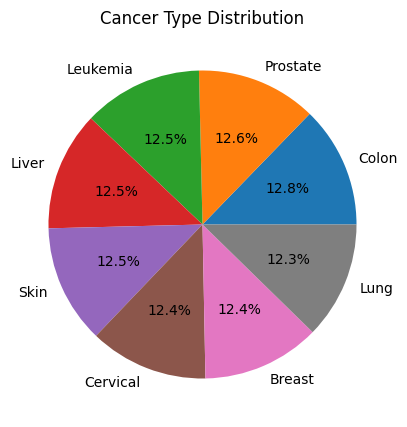

In [32]:
plt.figure(figsize=(5,5))
plt.pie(x=df['Cancer_Type'].value_counts().values,
        labels=df['Cancer_Type'].value_counts().index,
        autopct="%1.1f%%")
plt.title("Cancer Type Distribution")
plt.show()

#### inferences of cancer_types

* Nearly Uniform Distribution

  Each cancer type has approximately 6,200–6,400 cases (~12–13%).
  
* Suitable for Comparative Analysis

In [35]:
# cancer_stage

In [36]:
df['Cancer_Stage'].value_counts()

Cancer_Stage
Stage II     10124
Stage I      10046
Stage III    10008
Stage IV      9933
Stage 0       9889
Name: count, dtype: int64

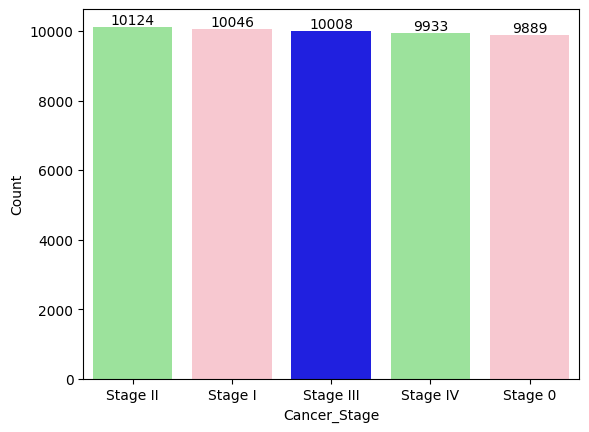

In [37]:
sns.barplot(x=df["Cancer_Stage"].value_counts().index,y=df["Cancer_Stage"].value_counts().values,color="lightblue",palette=["lightgreen","pink","blue"])
for x,v in enumerate(df["Cancer_Stage"].value_counts()):
    plt.text(x,v,str(v),ha="center",va="bottom")
plt.xlabel("Cancer_Stage")
plt.ylabel("Count")
plt.show()

#### Inferences

* cancer_stage contains 5 stages from 0 to 4 ,with stage 2 is most common followed by stage 1
* Nearly Uniform Distribution

In [40]:
#'Treatment_Cost_USD'


In [41]:
df['Treatment_Cost_USD']

0        62913.44
1        12573.41
2         6984.33
3        67446.25
4        77977.12
           ...   
49995    71463.70
49996    49619.66
49997     5338.25
49998    45100.47
49999    64023.82
Name: Treatment_Cost_USD, Length: 50000, dtype: float64

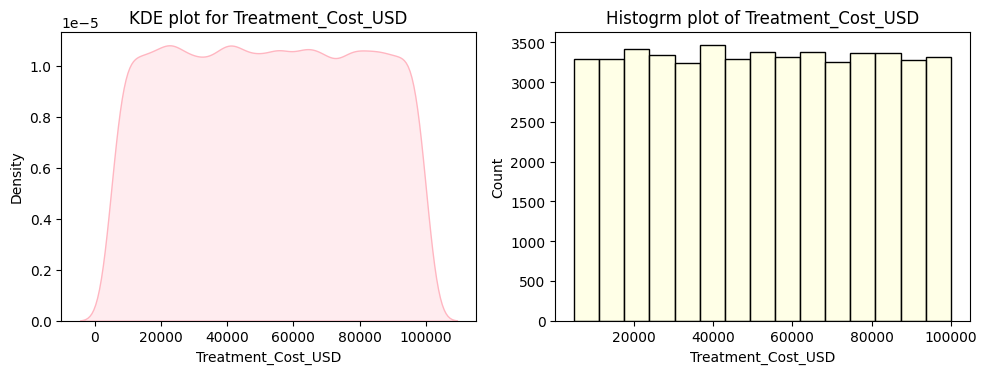

In [42]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.kdeplot(data=df["Treatment_Cost_USD"],fill=True,color="lightpink")
plt.title("KDE plot for Treatment_Cost_USD")

plt.subplot(1,2,2)
sns.histplot(data=df["Treatment_Cost_USD"],bins=15,color="lightyellow")
plt.title("Histogrm plot of Treatment_Cost_USD")

plt.tight_layout()
plt.show()

In [43]:
df["Treatment_Cost_USD"].describe()

count    50000.000000
mean     52467.298239
std      27363.229379
min       5000.050000
25%      28686.225000
50%      52474.310000
75%      76232.720000
max      99999.840000
Name: Treatment_Cost_USD, dtype: float64

#### inference

* Average Treatment Cost is High
* Mean ≈ Median (Symmetric Distribution)
* Quartile Interpretation

  25% of patients spent less than $28,686

  50% spent less than $52,474

  75% spent less than $76,232

#### Analysing Risk Factors

In [47]:
cols=['Genetic_Risk','Air_Pollution', 'Alcohol_Use', 'Smoking', 'Obesity_Level']

In [48]:
df[cols].agg(["mean","median","std","min","max"])

,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level
mean,5.001698,5.010126,5.010880,4.989826,4.991176
median,5.000000,5.000000,5.000000,5.000000,5.000000
std,2.885773,2.888399,2.888769,2.881579,2.894504
min,0.000000,0.000000,0.000000,0.000000,0.000000
max,10.000000,10.000000,10.000000,10.000000,10.000000


#### inferences

The 'Genetic_Risk','Air_Pollution', 'Alcohol_Use', 'Smoking', 'Obesity_Level' shows balanced, moderately distributed lifestyle and environmental risk factors, with good variability and no extreme skewness — making it suitable for correlation and interactive analysis (eg:gentic and smoking)

### Determine Relationship between Riskfactor and Target_Severity_Score

In [52]:
from scipy.stats import linregress

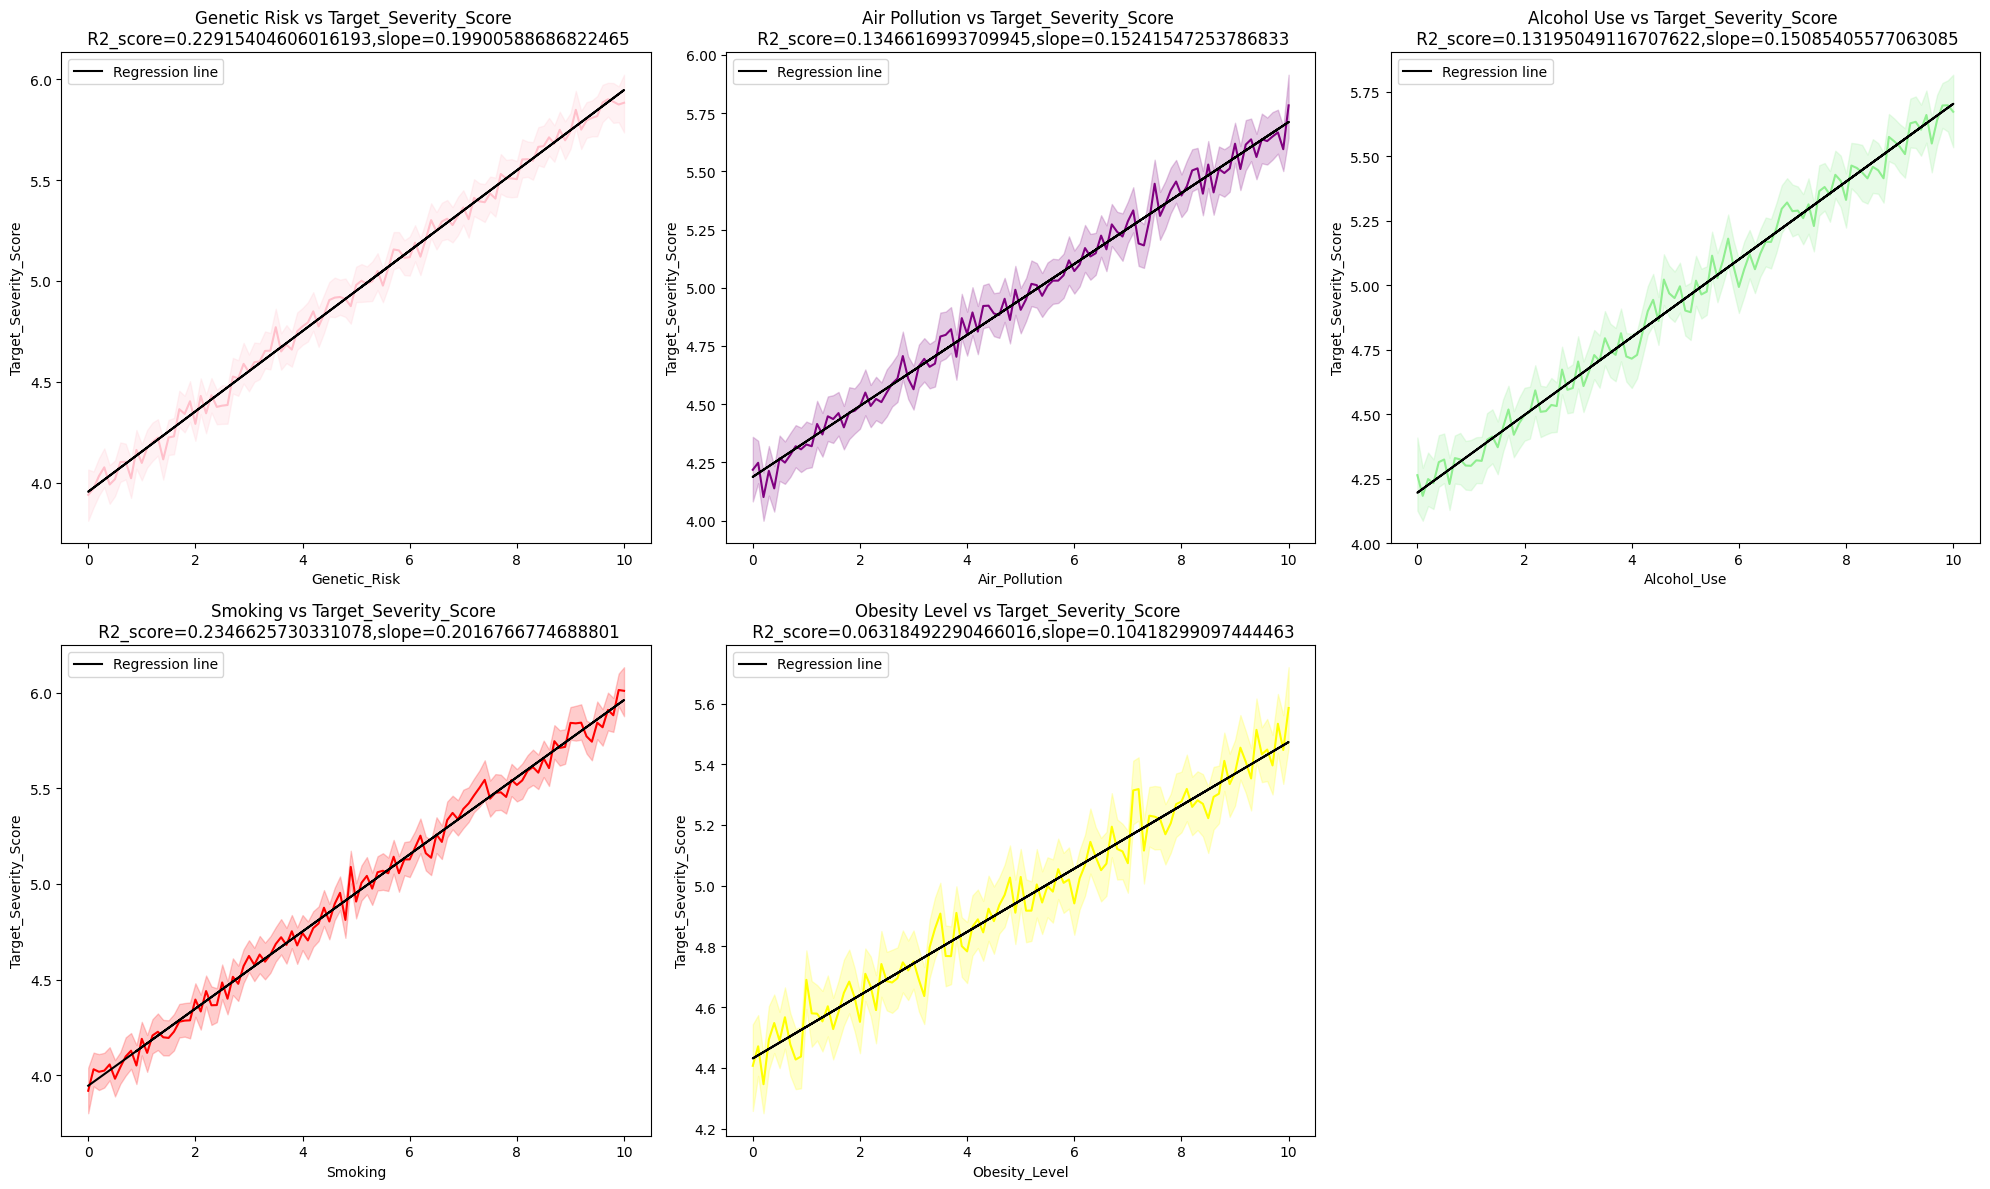

In [53]:
factors=['Genetic_Risk','Air_Pollution', 'Alcohol_Use', 'Smoking', 'Obesity_Level']
title=['Genetic Risk','Air Pollution', 'Alcohol Use', 'Smoking', 'Obesity Level']
color=["pink","purple","lightgreen","red",'yellow']
plt.figure(figsize=(20,12))
for i,(factors,title,color) in enumerate(zip(factors,title,color),1):
    plt.subplot(2,3,i)
    x=df[factors]
    y=df["Target_Severity_Score"]
    slope,intercept,rvalue,pvalue,stderr=linregress(x,y)
    r2_score=rvalue**2
    sns.lineplot(x=factors,y="Target_Severity_Score",data=df,color=color)
    plt.plot(x,x*slope+intercept,color="black",label="Regression line")
    plt.title(f"{title} vs Target_Severity_Score \n R2_score={r2_score},slope={slope}")
    plt.xlabel(factors)
    plt.ylabel("Target_Severity_Score")
    plt.legend()
plt.tight_layout()
plt.show()

#### Genetic Risk vs Severity Score

* As genetic risk increases, severity score increases.

* For every 1-unit increase in genetic risk, severity increases by ~0.20.

* R² = 0.229 → About 22.9% of severity variation is explained by genetic risk.

* Genetic risk is a strong contributor to cancer severity but not the only determinant.

#### Air Pollution vs Severity Score

* Severity increases as air pollution increases.

* Explains about 13.5% of variability in severity.

#### Alcohol Use vs Severity Score

* ncreased alcohol use slightly increases severity.
* Explains about 13.2% of severity variation.

#### Smoking vs Severity Score

* For every 1-unit increase in smoking, severity increases by ~0.20.

* Explains 23.5% of severity variability (highest)

* Smoking is the most influential lifestyle factor affecting cancer severity in this dataset.

#### Obesity Level vs Severity Score

* Small increase in severity with obesity.

* Explains only 6.3% of variation.

#### key factors

* All risk factors show positive relationships with severity.

* Smoking and Genetic Risk are the most impactful predictors.

* Obesity shows the weakest influence.

* Since R² values are below 0.25, severity is likely influenced by multiple combined factors, not a single risk variable.

Key Takeaways:

Weak Linear Relationships:
The R² values for all risk factors are relatively low, ranging from 0.06 to 0.23. This indicates that while there is some relationship between these risk factors and the Target_Severity_Score, it is weak. These factors alone do not explain much of the variation in the target variable.

Positive Trends:
All the slope values are positive, suggesting that as each risk factor increases, the Target_Severity_Score tends to increase as well. However, because the R² values are low, this increase is not strongly consistent across all data points.

Other Influences:
The low R² values imply that other, unmeasured factors are likely contributing to the variation in Target_Severity_Score. The risk factors you examined are only weakly correlated with the target and are not reliable predictors on their own.

Next Steps:
Given the weak explanatory power of these individual factors, it might be useful to explore other variables or more complex models that could account for more of the variation in the Target_Severity_Score. This could include interactions between risk factors, adding new features, or applying more sophisticated regression techniques.

### Analyze the proportion of early stage diagnoses by cancer Type

In [67]:
df["Cancer_Type"].unique()

array(['Lung', 'Leukemia', 'Breast', 'Colon', 'Skin', 'Cervical',
       'Prostate', 'Liver'], dtype=object)

In [68]:
stage_counts=df[df["Cancer_Type"]=='Lung']["Cancer_Stage"].value_counts()
early_stage_sum=stage_counts.get("Stage 0",0)+stage_counts.get("Stage I",0)
total_sum=stage_counts.sum()
proprtion=(early_stage_sum/total_sum)*100
print(f" propostion of lung cancer at stage 0 and stage 1 is {proprtion}")


 propostion of lung cancer at stage 0 and stage 1 is 38.43156356551388


In [69]:
stage_counts=df[df["Cancer_Type"]=='Leukemia']["Cancer_Stage"].value_counts()
early_stage_sum=stage_counts.get("Stage 0",0)+stage_counts.get("Stage I",0)
total_sum=stage_counts.sum()
proprtion=(early_stage_sum/total_sum)*100
print(f" propostion of Leukemia cancer at stage 0 and stage 1 is {proprtion}")

 propostion of Leukemia cancer at stage 0 and stage 1 is 39.53080114905841


In [70]:
stage_counts=df[df["Cancer_Type"]=='Breast']["Cancer_Stage"].value_counts()
early_stage_sum=stage_counts.get("Stage 0",0)+stage_counts.get("Stage I",0)
total_sum=stage_counts.sum()
proprtion=(early_stage_sum/total_sum)*100
print(f" propostion of Breast cancer at stage 0 and stage 1 is {proprtion}")

 propostion of Breast cancer at stage 0 and stage 1 is 39.47325900791727


In [71]:
stage_counts=df[df["Cancer_Type"]=='Colon']["Cancer_Stage"].value_counts()
early_stage_sum=stage_counts.get("Stage 0",0)+stage_counts.get("Stage I",0)
total_sum=stage_counts.sum()
proprtion=(early_stage_sum/total_sum)*100
print(f" propostion of Colon cancer at stage 0 and stage 1 is {proprtion}")

 propostion of Colon cancer at stage 0 and stage 1 is 40.41718946047679


In [72]:
stage_counts=df[df["Cancer_Type"]=='Skin']["Cancer_Stage"].value_counts()
early_stage_sum=stage_counts.get("Stage 0",0)+stage_counts.get("Stage I",0)
total_sum=stage_counts.sum()
proprtion=(early_stage_sum/total_sum)*100
print(f" propostion of skin cancer at stage 0 and stage 1 is {proprtion}")

 propostion of skin cancer at stage 0 and stage 1 is 40.41084898090194


In [73]:
stage_counts=df[df["Cancer_Type"]=='Cervical']["Cancer_Stage"].value_counts()
early_stage_sum=stage_counts.get("Stage 0",0)+stage_counts.get("Stage I",0)
total_sum=stage_counts.sum()
proprtion=(early_stage_sum/total_sum)*100
print(f" propostion of Cervical cancer at stage 0 and stage 1 is {proprtion}")

 propostion of Cervical cancer at stage 0 and stage 1 is 39.85856637737062


In [74]:
stage_counts=df[df["Cancer_Type"]=='Prostate']["Cancer_Stage"].value_counts()
early_stage_sum=stage_counts.get("Stage 0",0)+stage_counts.get("Stage I",0)
total_sum=stage_counts.sum()
proprtion=(early_stage_sum/total_sum)*100
print(f" propostion of Prostate cancer at stage 0 and stage 1 is {proprtion}")

 propostion of Prostate cancer at stage 0 and stage 1 is 40.187064045656314


In [75]:
stage_counts=df[df["Cancer_Type"]=='Liver']["Cancer_Stage"].value_counts()
early_stage_sum=stage_counts.get("Stage 0",0)+stage_counts.get("Stage I",0)
total_sum=stage_counts.sum()
proprtion=(early_stage_sum/total_sum)*100
print(f" propostion of Liver cancer at stage 0 and stage 1 is {proprtion}")

 propostion of Liver cancer at stage 0 and stage 1 is 40.614498319731155


### Identifying key predictors of cancer severity and surviual years

In [77]:
features=['Age','Genetic_Risk','Air_Pollution', 'Alcohol_Use', 'Smoking', 'Obesity_Level']

target=['Survival_Years','Target_Severity_Score']

pearson_corr=df[features+target].corr(method="pearson")

spearman_corr=df[features+target].corr(method='spearman')

In [78]:
pearson_corr[target]

,Survival_Years,Target_Severity_Score
Age,-0.000147,-0.001481
Genetic_Risk,0.001708,0.478700
Air_Pollution,0.000893,0.366963
Alcohol_Use,-0.000527,0.363250
Smoking,0.001371,0.484420
Obesity_Level,0.009771,0.251366
Survival_Years,1.000000,0.004161
Target_Severity_Score,0.004161,1.000000


In [79]:
spearman_corr[target]

,Survival_Years,Target_Severity_Score
Age,-0.000149,-0.002076
Genetic_Risk,0.001684,0.472193
Air_Pollution,0.000841,0.357528
Alcohol_Use,-0.000543,0.354694
Smoking,0.001372,0.477881
Obesity_Level,0.009780,0.243152
Survival_Years,1.000000,0.003431
Target_Severity_Score,0.003431,1.000000


In [80]:
corr_df=pd.concat([pearson_corr[target],spearman_corr[target]],axis=1,keys=["pearson","spearman"])

In [81]:
corr_df

pearson                             spearman  \
                      Survival_Years Target_Severity_Score Survival_Years   
Age                        -0.000147             -0.001481      -0.000149   
Genetic_Risk                0.001708              0.478700       0.001684   
Air_Pollution               0.000893              0.366963       0.000841   
Alcohol_Use                -0.000527              0.363250      -0.000543   
Smoking                     0.001371              0.484420       0.001372   
Obesity_Level               0.009771              0.251366       0.009780   
Survival_Years              1.000000              0.004161       1.000000   
Target_Severity_Score       0.004161              1.000000       0.003431   

                                             
                      Target_Severity_Score  
Age                               -0.002076  
Genetic_Risk                       0.472193  
Air_Pollution                      0.357528  
Alcohol_Use                        0.354694  
Smoking                            0.477881  
Obesity_Level                      0.243152  
Survival_Years                     0.003431  
Target_Severity_Score              1.000000

#### Target_Severity_Score

| Factor        | Pearson | Spearman | Strength               |
| ------------- | ------- | -------- | ---------------------- |
| Smoking       | 0.484   | 0.478    | Strong Positive        |
| Genetic_Risk  | 0.479   | 0.472    | Strong Positive        |
| Air_Pollution | 0.367   | 0.358    | Moderate Positive      |
| Alcohol_Use   | 0.363   | 0.355    | Moderate Positive      |
| Obesity_Level | 0.251   | 0.243    | Weak–Moderate Positive |
| Age           | -0.001  | -0.002   | No Relationship        |

#### Inference for Severity Score

* Severity increases as risk factors increase.

* Smoking and Genetic Risk are the strongest contributors.

* Environmental and lifestyle factors moderately influence severity.

* Age does not significantly impact severity in this dataset.

* Severity is largely influenced by behavioral and genetic factors.

* Target_Severity_Score is strongly driven by smoking and genetic predisposition, moderately by pollution and alcohol, and weakly by obesity.

#### Survival_Years

* Correlation Summary (Pearson)

All correlations ≈ 0 (between -0.001 and 0.01)

####  random forest for target severity score

In [87]:
# random forest for target severity score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score

In [88]:
df.columns

Index(['Patient_ID', 'Age', 'Gender', 'Country_Region', 'Year', 'Genetic_Risk',
       'Air_Pollution', 'Alcohol_Use', 'Smoking', 'Obesity_Level',
       'Cancer_Type', 'Cancer_Stage', 'Treatment_Cost_USD', 'Survival_Years',
       'Target_Severity_Score'],
      dtype='object')

In [89]:
cat_cols=['Gender', 'Country_Region','Cancer_Type', 'Cancer_Stage']

In [90]:
for i in cat_cols:
    le=LabelEncoder()
    df[i]=le.fit_transform(df[i])

In [91]:
x=df.drop(columns=['Patient_ID','Treatment_Cost_USD', 'Survival_Years','Target_Severity_Score'])

In [92]:
y_s=df['Target_Severity_Score']

In [93]:
x_train_s,x_test_s,y_train_s,y_test_s=train_test_split(x,y_s,test_size=0.2,random_state=123)

In [94]:
model=RandomForestRegressor(n_estimators=200,max_depth=None,min_samples_split=2,min_samples_leaf=1,random_state=409)

In [95]:
model.fit(x_train_s,y_train_s)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [96]:
train_r2_s=r2_score(y_train_s,model.predict(x_train_s))
test_r2_s=r2_score(y_test_s,model.predict(x_test_s))

In [97]:
print(train_r2_s)
print(test_r2_s)

0.968930526342843
0.7702350396000985


In [98]:
feature_importance_s=pd.Series(model.feature_importances_,index=x.columns).sort_values(ascending=True)

In [99]:
# plotting of feature_importance

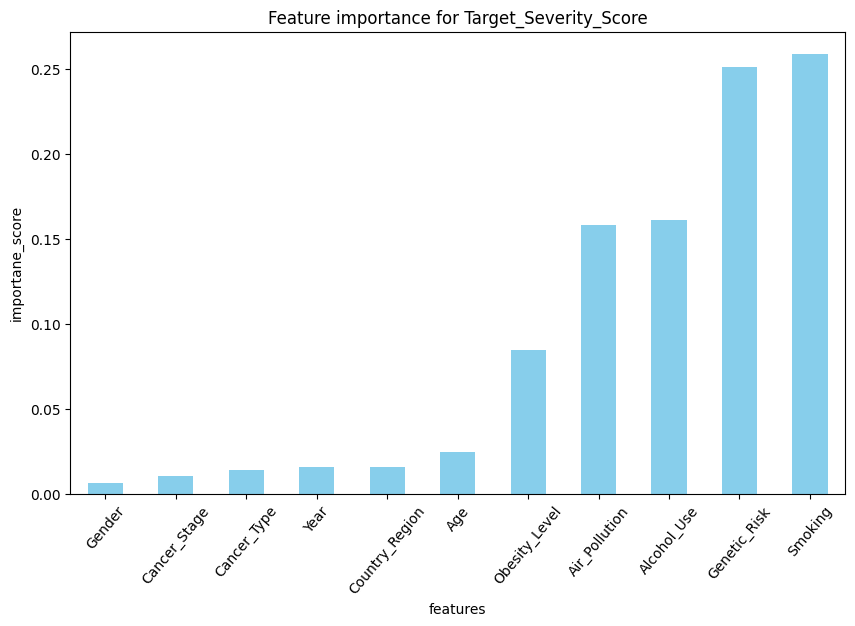

In [100]:
plt.figure(figsize=(10,6))
feature_importance_s.plot(kind="bar",color="skyblue")
plt.title("Feature importance for Target_Severity_Score")
plt.xlabel("features")
plt.ylabel("importane_score")
plt.xticks(rotation=50)
plt.show()

### Conclusion Points on Feature Importance

* **Smoking** has the highest importance score (0.259), making it the **most significant factor influencing the Target Severity Score**.
* **Genetic Risk** (0.251) is the **second most important feature**, indicating that hereditary factors strongly affect cancer severity.
* **Alcohol Use** (0.161) and **Air Pollution** (0.158) also have **high influence**, showing that lifestyle habits and environmental exposure contribute significantly to severity.
* **Obesity Level** (0.085) has a **moderate impact** on the prediction of cancer severity.
* **Age** (0.024) has a **small influence**, suggesting it plays a limited role in determining the severity score.
* **Country Region, Year, Cancer Type, Cancer Stage, and Gender** have **very low importance values**, meaning they contribute minimally to the model's prediction.
* Overall, **lifestyle factors and genetic risk are the most critical predictors of cancer severity in this dataset**, while demographic and regional factors have less impact.


In [102]:
####  random forest for target Survival_Years
from sklearn.model_selection import GridSearchCV

In [103]:
x=df.drop(columns=['Patient_ID','Treatment_Cost_USD', 'Survival_Years','Target_Severity_Score'])
y_su=df['Survival_Years']
x_train_s, x_test_s, y_train_s, y_test_s= train_test_split(x, y_su, test_size=0.2, random_state=40)

parm_grid={
    'n_estimators':[100,200],
    'max_depth':[5,10,None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
model_s=RandomForestRegressor(random_state=40)
GSC=GridSearchCV(model_s,parm_grid,cv=3,scoring="r2",n_jobs=-1)
GSC.fit(x_train_s, y_train_s)

best_rf_survival= GSC.best_estimator_
# evalaute the model

In [104]:
# evalaute the model
train_r2_severity= r2_score(y_train_s ,best_rf_survival.predict(x_train_s))
test_r2_severity= r2_score(y_test_s , best_rf_survival.predict(x_test_s))

print(train_r2_severity)
print(test_r2_severity)

0.008998065861791527
-0.0003487352301700941


In [106]:
data=pd.read_csv("C://Users//lenovo//Downloads//archive (3)//global_cancer_patients_2015_2024.csv")

<Axes: xlabel='Survival_Years', ylabel='Count'>

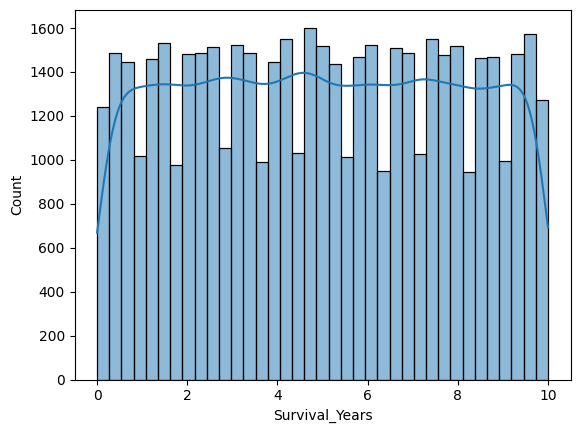

In [108]:
import seaborn as sns
sns.histplot(data["Survival_Years"], kde=True)

In [110]:
df.corr(numeric_only=True)["Survival_Years"].sort_values(ascending=True)

Gender                  -0.007121
Cancer_Stage            -0.003014
Cancer_Type             -0.001717
Alcohol_Use             -0.000527
Treatment_Cost_USD      -0.000429
Age                     -0.000147
Year                     0.000018
Air_Pollution            0.000893
Smoking                  0.001371
Genetic_Risk             0.001708
Target_Severity_Score    0.004161
Country_Region           0.005121
Obesity_Level            0.009771
Survival_Years           1.000000
Name: Survival_Years, dtype: float64

"The information in your columns does not help the model figure out how long someone will survive."`

# Explore the economic burden of cancer treatment across different demographics and countries

In [114]:
data.head()

,Patient_ID,Age,Gender,Country_Region,Year,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Cancer_Type,Cancer_Stage,Treatment_Cost_USD,Survival_Years,Target_Severity_Score
0,PT0000000,71,Male,UK,2021,6.4,2.8,9.5,0.9,8.7,Lung,Stage III,62913.44,5.9,4.92
1,PT0000001,34,Male,China,2021,1.3,4.5,3.7,3.9,6.3,Leukemia,Stage 0,12573.41,4.7,4.65
2,PT0000002,80,Male,Pakistan,2023,7.4,7.9,2.4,4.7,0.1,Breast,Stage II,6984.33,7.1,5.84
3,PT0000003,40,Male,UK,2015,1.7,2.9,4.8,3.5,2.7,Colon,Stage I,67446.25,1.6,3.12
4,PT0000004,43,Female,Brazil,2017,5.1,2.8,2.3,6.7,0.5,Skin,Stage III,77977.12,2.9,3.62


In [116]:
data["Age_groups"]=pd.cut(data["Age"],bins=[0,30,45,60,75,100],labels=["0-30","31-45","46-60","61-75","76+"])

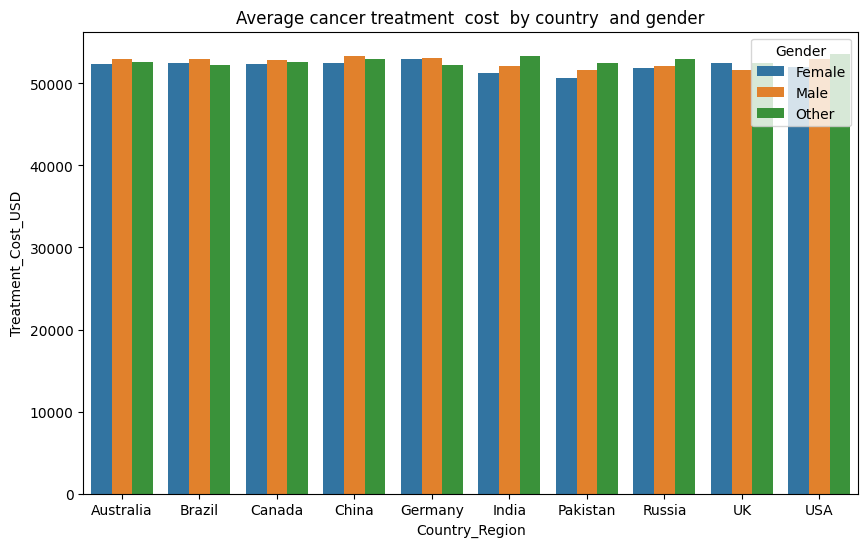

In [118]:
country_gender_cost=(data.groupby(["Country_Region","Gender"])["Treatment_Cost_USD"].mean()).reset_index()
plt.figure(figsize=(10,6))
sns.barplot(data=country_gender_cost,x="Country_Region",y="Treatment_Cost_USD",hue="Gender")
plt.title("Average cancer treatment  cost  by country  and gender")
plt.show()

### Conclusions from the Data (Economic Burden of Cancer Treatment by Country and Gender)

* The **average cancer treatment cost across all countries ranges between about $50,000 and $53,600**, showing that cancer treatment is **expensive globally**.

* **USA (Other gender – $53,632)** has the **highest average treatment cost** among all groups, indicating a higher economic burden in that case.

* **Pakistan (Female – $50,597)** has the **lowest average treatment cost** in the dataset.

* In most countries, **male patients have slightly higher treatment costs than female patients**, although the difference is not very large.

* Some countries such as **India, Russia, and the USA show higher costs for the “Other” gender group**, suggesting slight variation in treatment cost distribution.

* **Pakistan and India generally show lower treatment costs compared to countries like Germany, China, and the USA**.


In [120]:
country_age_cost=(data.groupby(["Country_Region","Age_groups"])["Treatment_Cost_USD"].mean()).reset_index()
heatmap_data= country_age_cost.pivot(index="Age_groups", columns="Country_Region", values="Treatment_Cost_USD")

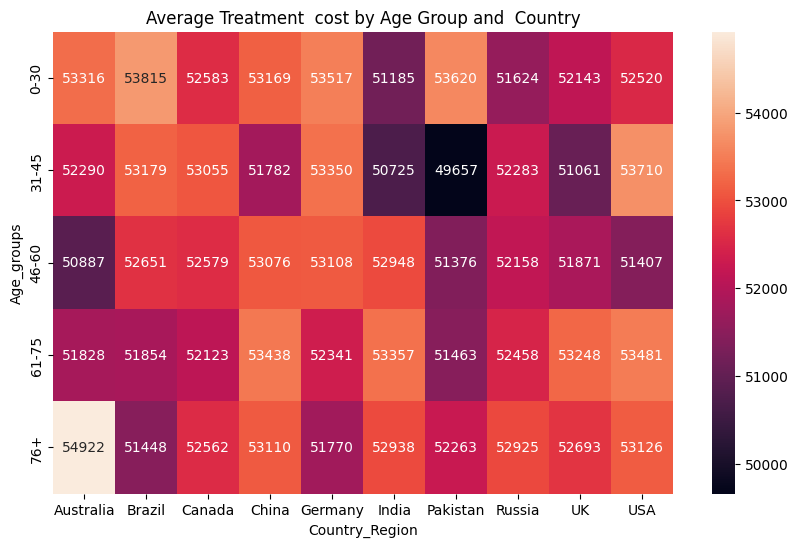

In [122]:
plt.figure(figsize=(10,6))
sns.heatmap(heatmap_data, annot=True, fmt=".0f")
plt.title("Average Treatment  cost by Age Group and  Country")
plt.show()

### Conclusions from the Average Treatment  cost by Age Group and  Country

* The **average cancer treatment cost across all countries and age groups ranges roughly between $49,000 and $55,000**, indicating a consistently high economic burden.

* The **76+ age group in Australia (~$54,922)** shows one of the **highest treatment costs**, suggesting older patients may require more expensive care.

* **Pakistan (31–45 age group ~$49,657)** shows the **lowest treatment cost** among the listed groups.

* In many countries such as **China, India, and the USA**, treatment costs remain **fairly consistent across different age groups**, with only small variations.

* Overall, the data suggests that **cancer treatment costs are high in all countries regardless of age group**, with only moderate differences between countries and age ranges.


# Assess whether higher treatment cost is associated with longer survival

Null Hypothesis (H₀) :- There is no correlation between treatment cost and survival years.
Alternative Hypothesis (H₁):- There is a correlation (positive or negative) between treatment cost and survival years.``

In [128]:
print(data["Treatment_Cost_USD"].corr(data["Survival_Years"]))

-0.00042940542830216386


In [130]:
from scipy.stats import pearsonr, spearmanr
x=data["Treatment_Cost_USD"]
y=data["Survival_Years"]
pearson_corr,pearson_p=pearsonr(x,y)
print("pearson_correlation_cofficent :",pearson_corr)
print("pearson_p_value :",pearson_p)
spearman_corr,spearman_p=spearmanr(x,y)
print("spearman_correlation_cofficent :",spearman_corr)
print("spearman_p_value :",spearman_p)

alpha=0.05
def interpret_corr(corr, p, method):
    if p<alpha:
        print(f"{method}, we reject Null Hypothesis")
    else:
        print(f"{method}, we failed to reject Null Hypothesis")


interpret_corr(pearson_corr,pearson_p,"pearson")
interpret_corr(spearman_corr,spearman_p,"spearman")

pearson_correlation_cofficent : -0.0004294054283021471
pearson_p_value : 0.9235082012963326
spearman_correlation_cofficent : -0.0004454737292549569
spearman_p_value : 0.9206551702014918
pearson, we failed to reject Null Hypothesis
spearman, we failed to reject Null Hypothesis


<Axes: xlabel='Survival_Years', ylabel='Treatment_Cost_USD'>

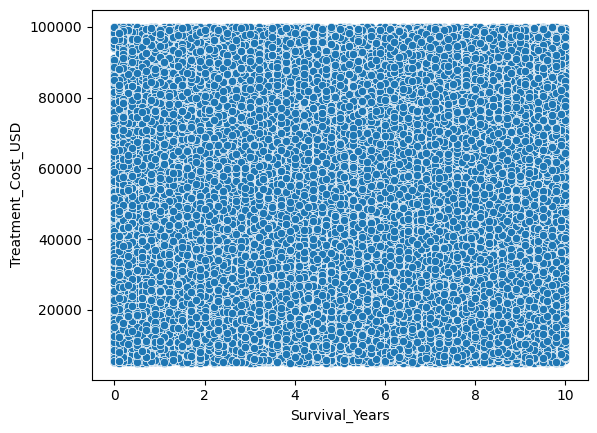

In [132]:
sns.scatterplot(data=data,x="Survival_Years",y="Treatment_Cost_USD")

### Conclusion for higher treatment cost is associated with longer survival years :
**Problem Statement:** *Assess whether higher treatment cost is associated with longer survival years.*

* The **Pearson correlation (-0.00043)** and **Spearman correlation (-0.00045)** are both extremely close to **zero**, indicating **no meaningful relationship** between treatment cost and survival years.

* The **p-values (~0.92)** are **much greater than the significance level (0.05)**, meaning the relationship is **not statistically significant**.

* Since the **null hypothesis was not rejected**, the analysis suggests that **treatment cost does not significantly influence how long patients survive** in this dataset.

* This implies that **spending more on treatment does not necessarily result in longer survival**, and other factors such as **genetic risk, lifestyle factors, or cancer severity** may play a more important role.


# Evaluate if higher cancer stages lead to greater treatment costs and reduced survival years

In [144]:
df=data.copy()

In [158]:
grouped_stage=df.groupby(["Cancer_Stage"])[["Treatment_Cost_USD","Target_Severity_Score"]].mean().reset_index()

In [160]:
grouped_stage

,Cancer_Stage,Treatment_Cost_USD,Target_Severity_Score
0,Stage 0,52572.589493,4.949560
1,Stage I,52674.079638,4.948788
2,Stage II,52082.841258,4.966201
3,Stage III,52708.197506,4.940766
4,Stage IV,52302.471041,4.950533


Treatment Cost vs. Cancer Stage   
Null Hypothesis (H₀): The average treatment cost is the same across all cancer stages.    
Alternative Hypothesis (H₁): At least one stage has a different average cost.    
       
Survival Years vs. Cancer Stage      
Null Hypothesis (H₀): The average survival years are the same across all cancer stages.    
Alternative Hypothesis (H₁): At least one stage has a different survival duration.    


In [177]:
stage_order = ['Stage 0', 'Stage I', 'Stage II', 'Stage III', 'Stage IV']

In [182]:
#Treatment_Cost_USD
from scipy.stats import f_oneway
group=[]
for stage in stage_order:
    group.append(df[df['Cancer_Stage']==stage]['Treatment_Cost_USD'])
    
f_stat, p_value = f_oneway(*group)

print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 0.9636856344215731
p-value: 0.42603111773931435


In [188]:
#Target_Severity_Score
groups=[]
for stage in stage_order:
    groups.append(df[df['Cancer_Stage']==stage]['Target_Severity_Score'])
    
f_stat_t, p_value_t = f_oneway(*groups)

print("F-statistic:", f_stat_t)
print("p-value:", p_value_t)

F-statistic: 0.6005110378923119
p-value: 0.6622596308373122


### Inference and Conclusion from ANOVA Test

#### 1️⃣ Treatment Cost vs Cancer Stage

* **F-statistic:** 0.9637
* **p-value:** 0.4260

Since the **p-value (0.426) is greater than the significance level (0.05)**, we **fail to reject the null hypothesis**.

**Inference:**
There is **no statistically significant difference in the average treatment cost across different cancer stages**. This means that, based on this dataset, **treatment cost does not significantly increase or decrease with cancer stage**.

---

#### 2️⃣ Target Severity Score vs Cancer Stage

* **F-statistic:** 0.6005
* **p-value:** 0.6623

Since the **p-value (0.662) is greater than 0.05**, we again **fail to reject the null hypothesis**.

**Inference:**
There is **no statistically significant difference in the average Target Severity Score across cancer stages** in this dataset.

---

# Examine whether higher genetic risk amplifies the negative effects of smoking on cancer severity 

H₀: Genetic risk does not amplify the effect of smoking.      
H₁: Genetic risk amplifies the effect of smoking on cancer severity.

In [196]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

model = ols('Target_Severity_Score ~ Smoking * Genetic_Risk', data=df).fit()

anova_table = sm.stats.anova_lm(model, typ=2)

print(anova_table)

                            sum_sq       df             F    PR(>F)
Smoking               17010.818786      1.0  22113.808950  0.000000
Genetic_Risk          16614.426399      1.0  21598.504800  0.000000
Smoking:Genetic_Risk      0.180338      1.0      0.234437  0.628255
Residual              38458.905834  49996.0           NaN       NaN


### Inference and Conclusion

#### 1️⃣ Effect of Smoking on Cancer Severity

* **F-value:** 22113.81
* **p-value:** 0.000

Since the **p-value < 0.05**, smoking has a **statistically significant effect on cancer severity**.
This means **higher smoking levels are associated with higher cancer severity scores**.

---

#### 2️⃣ Effect of Genetic Risk on Cancer Severity

* **F-value:** 21598.50
* **p-value:** 0.000

Since the **p-value < 0.05**, genetic risk also has a **significant effect on cancer severity**.
This indicates that **individuals with higher genetic risk tend to have higher cancer severity scores**.

---

#### 3️⃣ Interaction Effect (Smoking × Genetic Risk)

* **F-value:** 0.234
* **p-value:** 0.628

Since the **p-value (0.628) > 0.05**, the interaction effect is **not statistically significant**.

This means **genetic risk does not significantly amplify the negative effect of smoking on cancer severity**.

---

### Final Conclusion

The analysis shows that **both smoking and genetic risk independently increase cancer severity**. However, the interaction between smoking and genetic risk is **not statistically significant**, indicating that **higher genetic risk does not amplify the impact of smoking on cancer severity in this dataset**.
